# Customer Churn EDA

This notebook performs an Exploratory Data Analysis (EDA) on the customer churn dataset located at `dataset/customer churn.csv.xlsx`. The goal is to understand the data, identify patterns, and gain insights into customer churn.
[Kaggle data set][def]

[def]: https://www.kaggle.com/datasets/gregorykipngeno/customer-churn-analysis-dataset?select=customer+churn.csv.xlsx

## 1. Import Required Libraries
Importing pandas, numpy, matplotlib, seaborn, and other libraries needed for EDA.

In [15]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 2. Load the Dataset
Load the Excel file using pandas' `read_excel` function.

In [16]:
!pwd

/home/marc/project/customer_churn_analysis


In [17]:
# Load the Dataset
df = pd.read_excel("dataset/customer churn.csv.xlsx")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,Credit Card,IsActiveMember,EstimatedSalary,Churned,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## 3. Inspect Data Structure
Display the first few rows, check the shape, and examine column names and data types.

In [18]:
# Inspect Data Structure
df.info()
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  Credit Card         10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Churned             10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

RowNumber               int64
CustomerId              int64
Surname                   str
CreditScore             int64
Geography                 str
Gender                    str
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
Credit Card             int64
IsActiveMember          int64
EstimatedSalary       float64
Churned                 int64
Complain                int64
Satisfaction Score      int64
Card Type                 str
Point Earned            int64
dtype: object

## 4. Handle Missing Values
Identify missing values and demonstrate strategies to handle them (e.g., imputation or removal).

In [19]:
# Handle Missing Values
missing = df.isnull().sum()
print(missing[missing > 0])
# Example: Impute or drop missing values as needed
df_clean = df.dropna()  # or use df.fillna(value) for imputation

Series([], dtype: int64)


NO missing values at all 

## 5. Summary Statistics
Generate descriptive statistics for numerical and categorical columns.

In [20]:
# Summary Statistics
print('Numerical Columns:')
display(df.describe())
print('\nCategorical Columns:')
display(df.describe(include=['object', 'category']))

Numerical Columns:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,Credit Card,IsActiveMember,EstimatedSalary,Churned,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000



Categorical Columns:


/tmp/ipykernel_219874/3632325742.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['object', 'category']))


,Surname,Geography,Gender,Card Type
count,10000,10000,10000,10000
unique,2932,3,2,4
top,Smith,France,Male,DIAMOND
freq,32,5014,5457,2507


## 6. Visualize Categorical Features
Create bar plots or count plots for categorical variables to understand their distributions.

/tmp/ipykernel_219874/1662777052.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


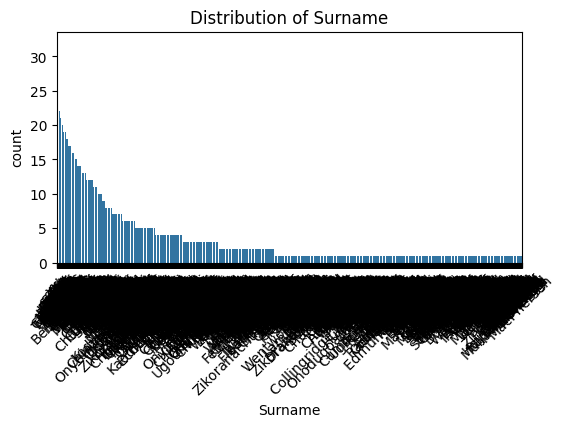

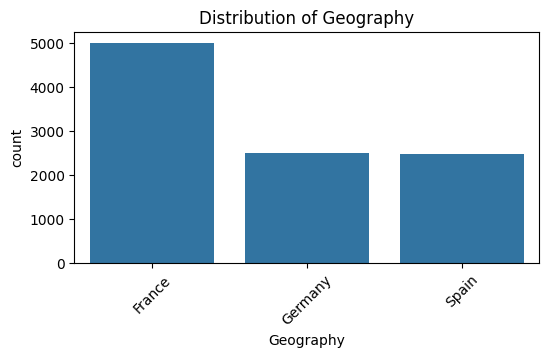

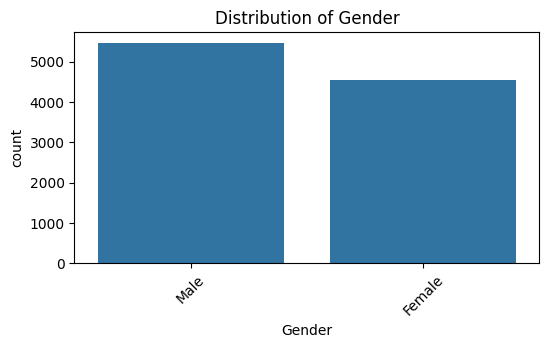

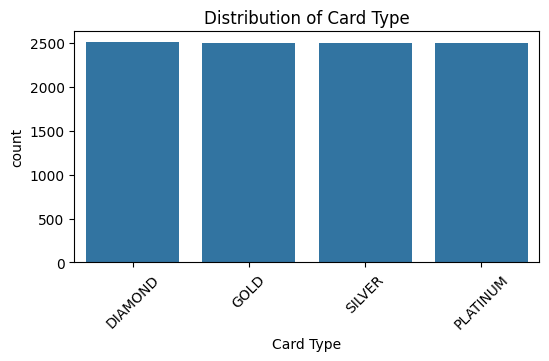

In [21]:
# Visualize Categorical Features
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

## 7. Visualize Numerical Features
Plot histograms, boxplots, or violin plots for numerical features to analyze their distributions and detect outliers.

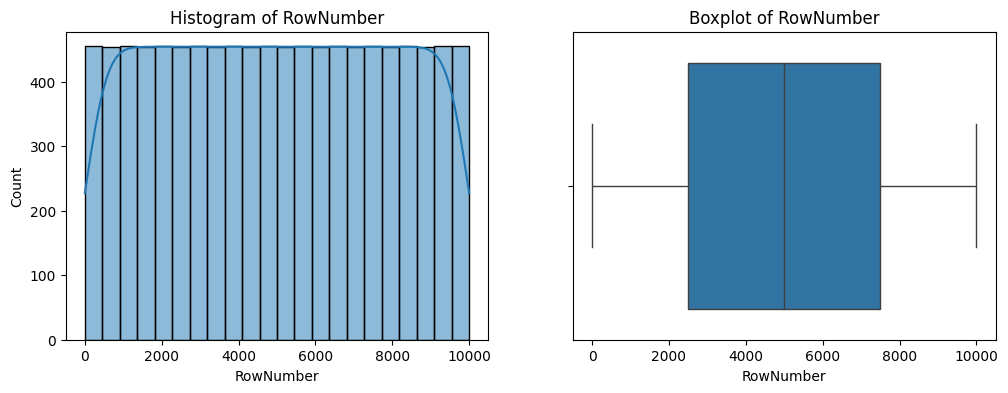

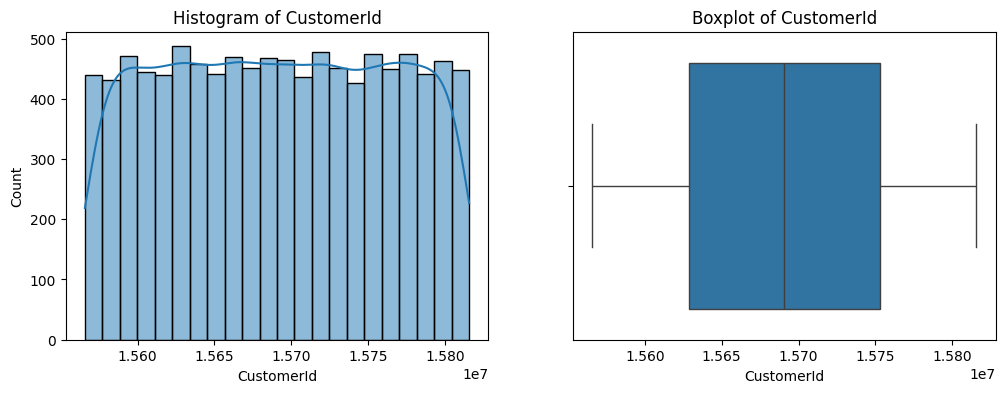

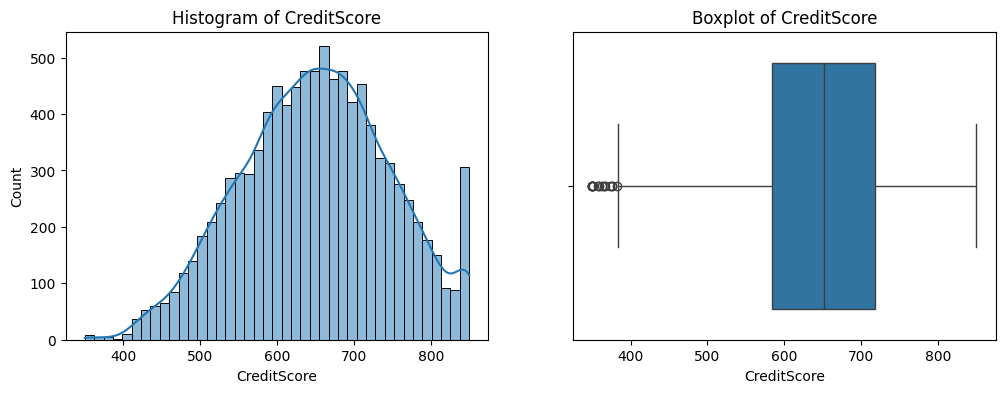

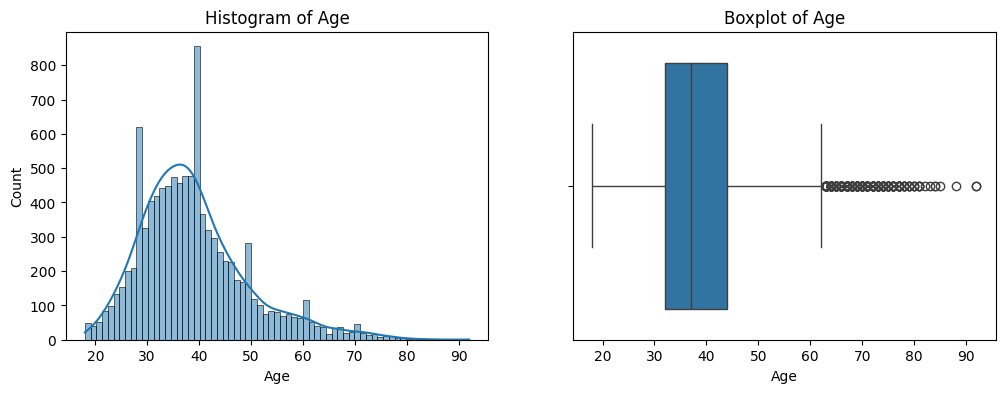

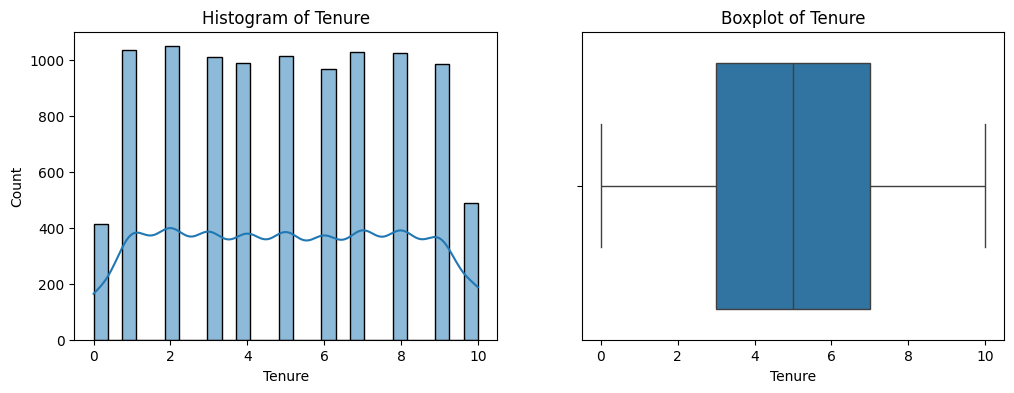

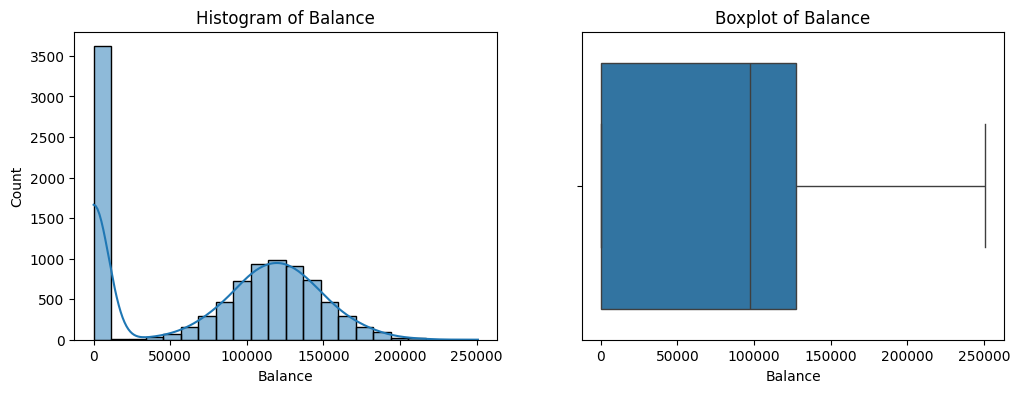

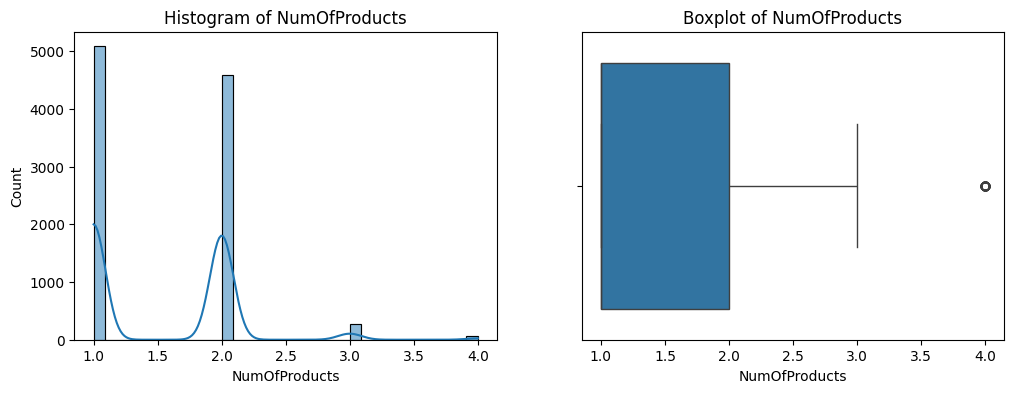

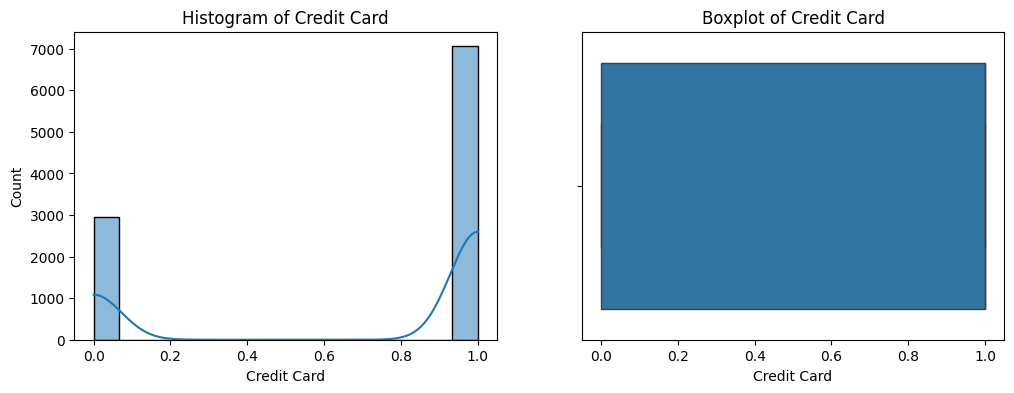

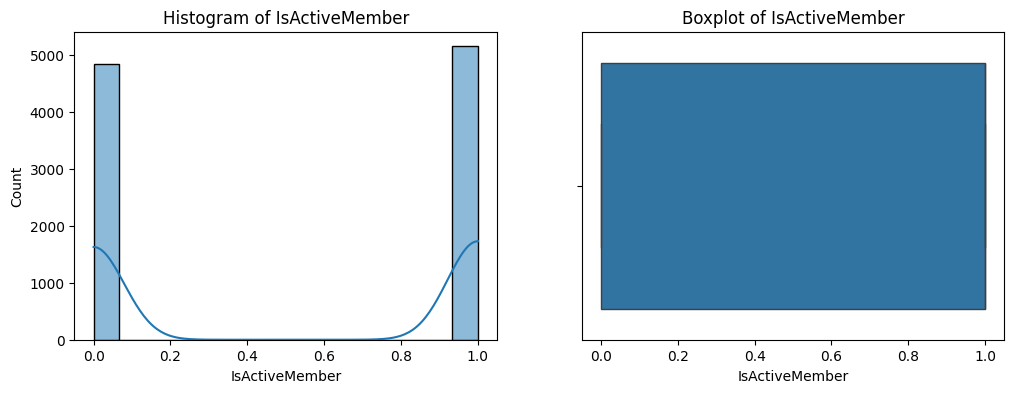

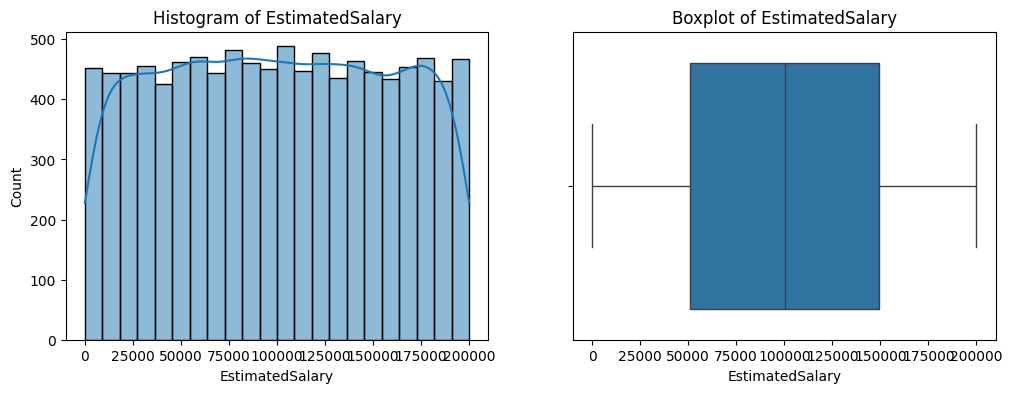

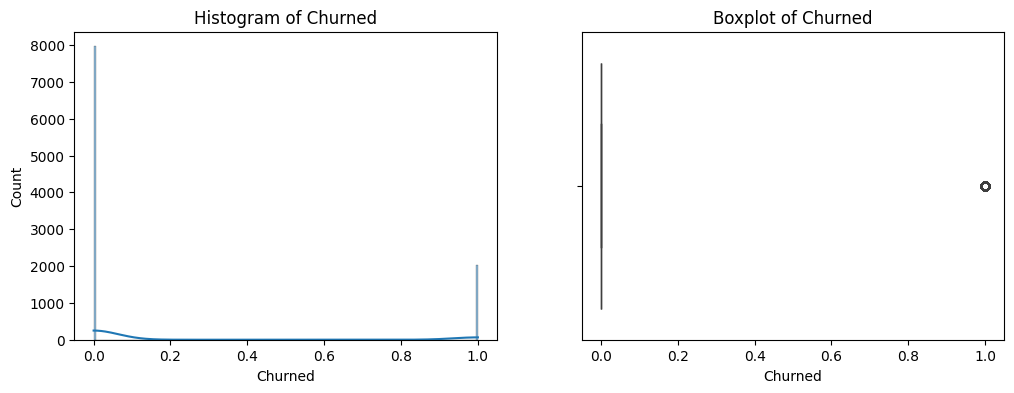

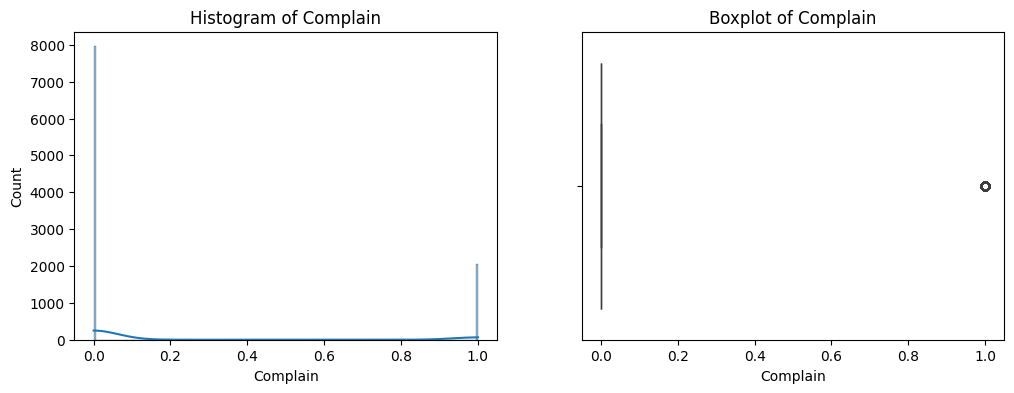

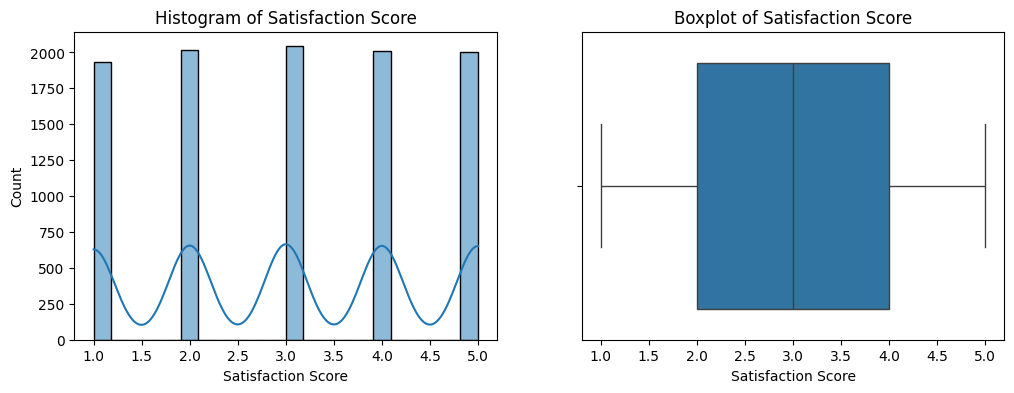

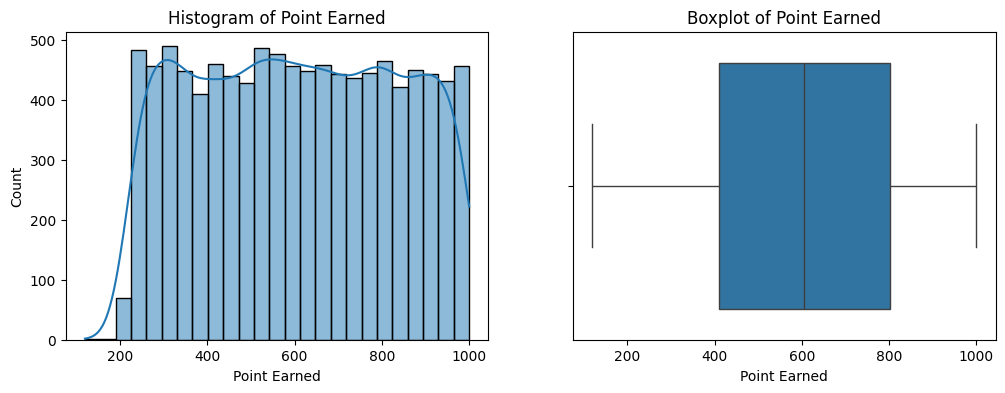

In [22]:
# Visualize Numerical Features
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    plt.show()

## 8. Correlation Analysis
Compute and visualize the correlation matrix for numerical features using a heatmap.

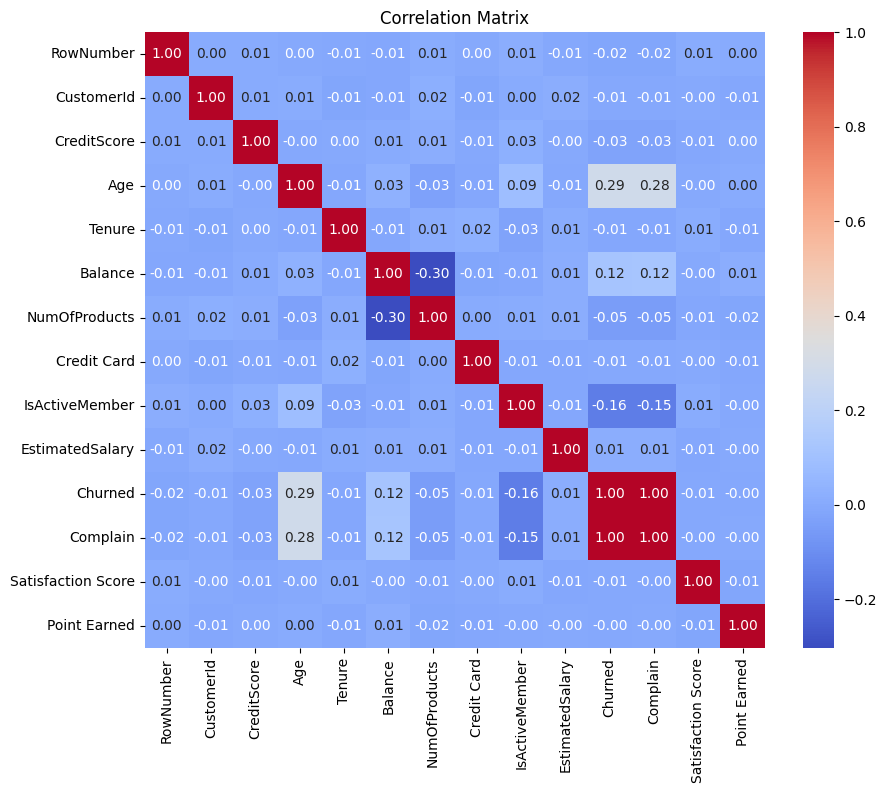

In [23]:
# Correlation Analysis
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 9. Churn Rate Analysis
Analyze the churn rate overall and across key features using groupby and visualization.

In [30]:
# Example: Calculate churn rate by a group column (e.g., 'Gender')
group_col = "IsActiveMember"  # e.g., "Gender", "Contract", etc.
churn_col = "Churned"     # Update if your churn column has a different name

churn_rate = df.groupby(group_col)[churn_col].apply(lambda x: (x == 1).sum() / x.count())
print(churn_rate)

IsActiveMember
0    0.268715
1    0.142691
Name: Churned, dtype: float64


In [32]:
# Example: Calculate churn rate by a group column (e.g., 'Gender')
group_col = "Age"  # e.g., "Gender", "Contract", etc.
churn_col = "Churned"     # Update if your churn column has a different name

churn_rate = df.groupby(group_col)[churn_col].apply(lambda x: (x == 1).sum() / x.count())
print(churn_rate)

Age
18    0.090909
19    0.037037
20    0.050000
21    0.056604
22    0.142857
        ...   
83    0.000000
84    0.500000
85    0.000000
88    0.000000
92    0.000000
Name: Churned, Length: 70, dtype: float64


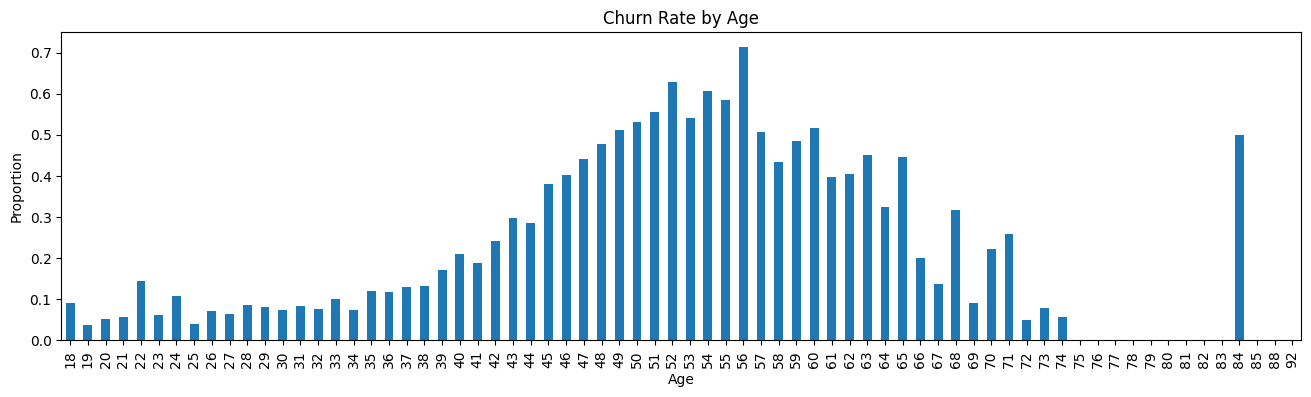

In [35]:
churn_rate.plot(kind='bar', stacked=True, figsize=(16,4))
plt.title(f'Churn Rate by {group_col}')
plt.ylabel('Proportion')
plt.show()

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64
(-250.899, 25089.809]       3623
(25089.809, 50179.618]        69
(50179.618, 75269.427]       360
(75269.427, 100359.236]     1173
(100359.236, 125449.045]    2081
(125449.045, 150538.854]    1747
(150538.854, 175628.663]     729
(175628.663, 200718.472]     186
(200718.472, 225808.281]      30
(225808.281, 250898.09]        2
Name: count, dtype: int64


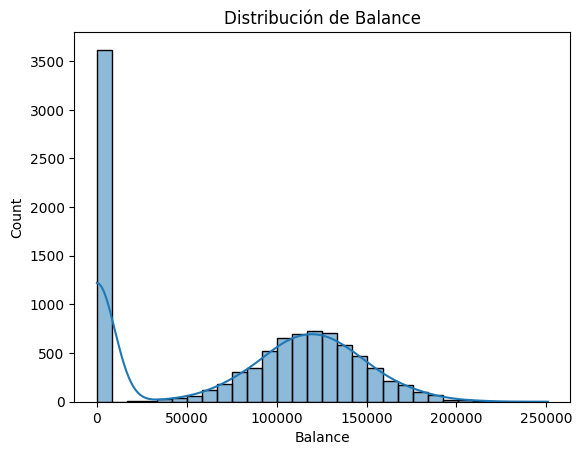

In [37]:
# Explora la columna Balance
print(df['Balance'].describe())
print(df['Balance'].value_counts(bins=10, sort=False))
sns.histplot(df['Balance'], bins=30, kde=True)
plt.title('Distribución de Balance')
plt.show()

count      6383.000000
mean     119827.493793
std       30095.056462
min        3768.690000
25%      100181.975000
50%      119839.690000
75%      139512.290000
max      250898.090000
Name: Balance, dtype: float64
(3521.56, 28481.63]         10
(28481.63, 53194.57]        82
(53194.57, 77907.51]       418
(77907.51, 102620.45]     1255
(102620.45, 127333.39]    2089
(127333.39, 152046.33]    1647
(152046.33, 176759.27]     679
(176759.27, 201472.21]     173
(201472.21, 226185.15]      28
(226185.15, 250898.09]       2
Name: count, dtype: int64


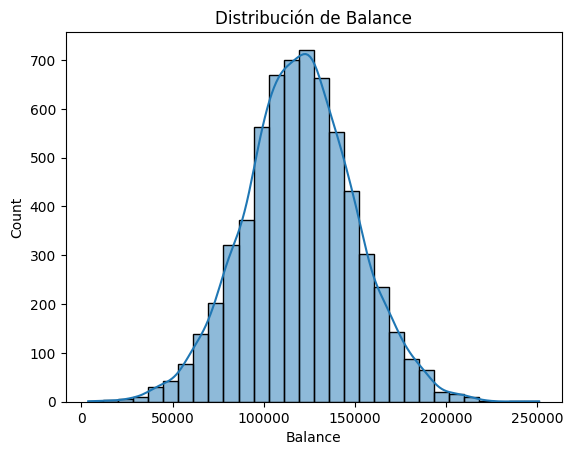

In [42]:
df_bal_positive = (df[df['Balance'] > 0])
print(df_bal_positive['Balance'].describe())
print(df_bal_positive['Balance'].value_counts(bins=10, sort=False))
sns.histplot(df_bal_positive['Balance'], bins=30, kde=True)
plt.title('Distribución de Balance')
plt.show()

In [40]:
len(df[df['Balance'] > 85000
       ])

5596

Balance
0.00         0.138236
3768.69      1.000000
12459.19     1.000000
14262.80     0.000000
16893.59     0.000000
               ...   
216109.88    1.000000
221532.80    0.000000
222267.63    1.000000
238387.56    1.000000
250898.09    1.000000
Name: Churned, Length: 6382, dtype: float64


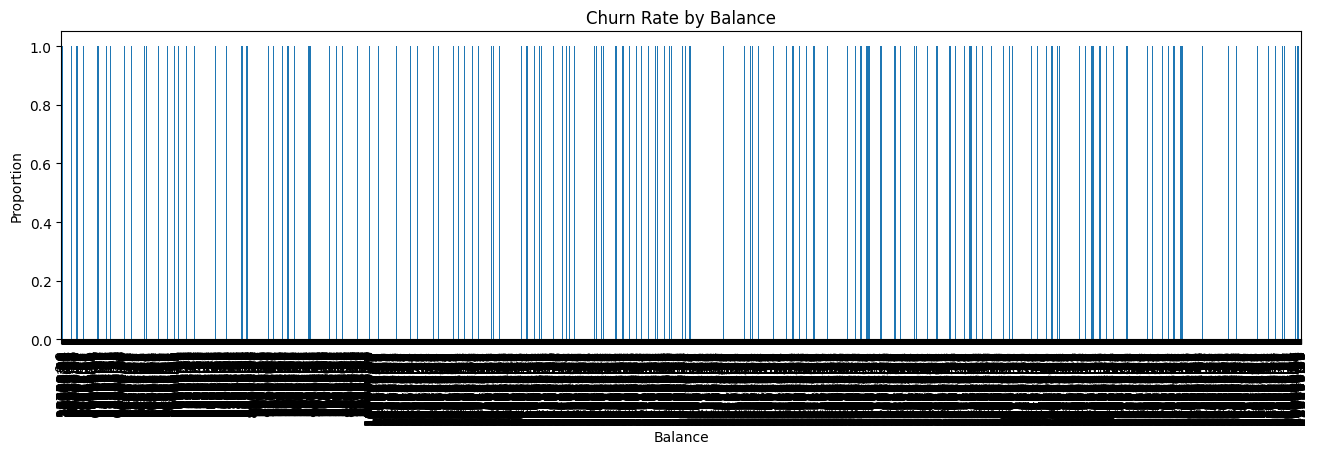

In [36]:
# Example: Calculate churn rate by a group column (e.g., 'Gender')
group_col = "Balance"  # e.g., "Gender", "Contract", etc.
churn_col = "Churned"     # Update if your churn column has a different name

churn_rate = df.groupby(group_col)[churn_col].apply(lambda x: (x == 1).sum() / x.count())
print(churn_rate)

churn_rate.plot(kind='bar', stacked=True, figsize=(16,4))
plt.title(f'Churn Rate by {group_col}')
plt.ylabel('Proportion')
plt.show()

In [27]:
# Churn Rate Analysis
# Replace 'Churn' with the actual churn column name if different
target_col = 'Churn'  # Update if needed
if target_col in df.columns:
    print('Overall churn rate:')
    print(df[target_col].value_counts(normalize=True))
    sns.countplot(data=df, x=target_col)
    plt.title('Churn Distribution')
    plt.show()
    # Churn rate by categorical features
    for col in categorical_cols:
        if col != target_col:
            churn_by_col = df.groupby(col)[target_col].value_counts(normalize=True).unstack().fillna(0)
            churn_by_col.plot(kind='bar', stacked=True, figsize=(8,4))
            plt.title(f'Churn Rate by {col}')
            plt.ylabel('Proportion')
            plt.show()

---

This concludes the EDA. You can further customize the analysis based on your dataset and business questions.

In [ ]:
# Crear columna balance_class según los rangos especificados de balance (0, el 25% con menor balance, el 50% con balance promedio, el 25% con balance alto)
bins = [-0.01, 0, 100181.975, 139512.29, np.inf]
labels = ['zero', 'lower', 'on_average', 'upper']
df['balance_class'] = pd.cut(df['Balance'], bins=bins, labels=labels)
df['balance_class'].value_counts()

balance_class
zero          3617
on_average    3191
lower         1596
upper         1596
Name: count, dtype: int64

In [50]:
len(df[df['Churned'] == 1])/len(df)

0.2038

In [49]:
df[df['Churned'] == 1]['balance_class'].value_counts(normalize=True)

balance_class
on_average    0.412659
zero          0.245339
upper         0.180079
lower         0.161923
Name: proportion, dtype: float64

balance_class
zero          0.138236
lower         0.206767
on_average    0.263554
upper         0.229950
Name: Churned, dtype: float64


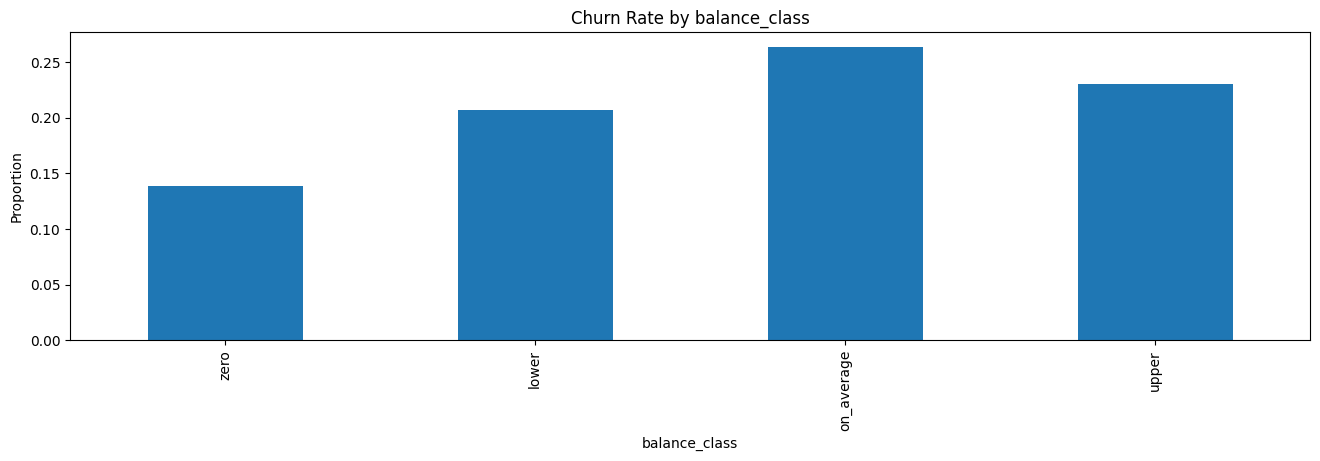

In [44]:
# Example: Calculate churn rate by a group column (e.g., 'Gender')
group_col = "balance_class"  # e.g., "Gender", "Contract", etc.
churn_col = "Churned"     # Update if your churn column has a different name

churn_rate = df.groupby(group_col)[churn_col].apply(lambda x: (x == 1).sum() / x.count())
print(churn_rate)

churn_rate.plot(kind='bar', stacked=True, figsize=(16,4))
plt.title(f'Churn Rate by {group_col}')
plt.ylabel('Proportion')
plt.show()

balance_bin
(1.0, 30001.0]          0.583333
(30001.0, 60001.0]      0.258741
(60001.0, 90001.0]      0.191566
(90001.0, 120001.0]     0.257104
(120001.0, 150001.0]    0.244575
(150001.0, 180001.0]    0.213844
(180001.0, 210001.0]    0.299320
(210001.0, 240001.0]    0.500000
Name: Churned, dtype: float64


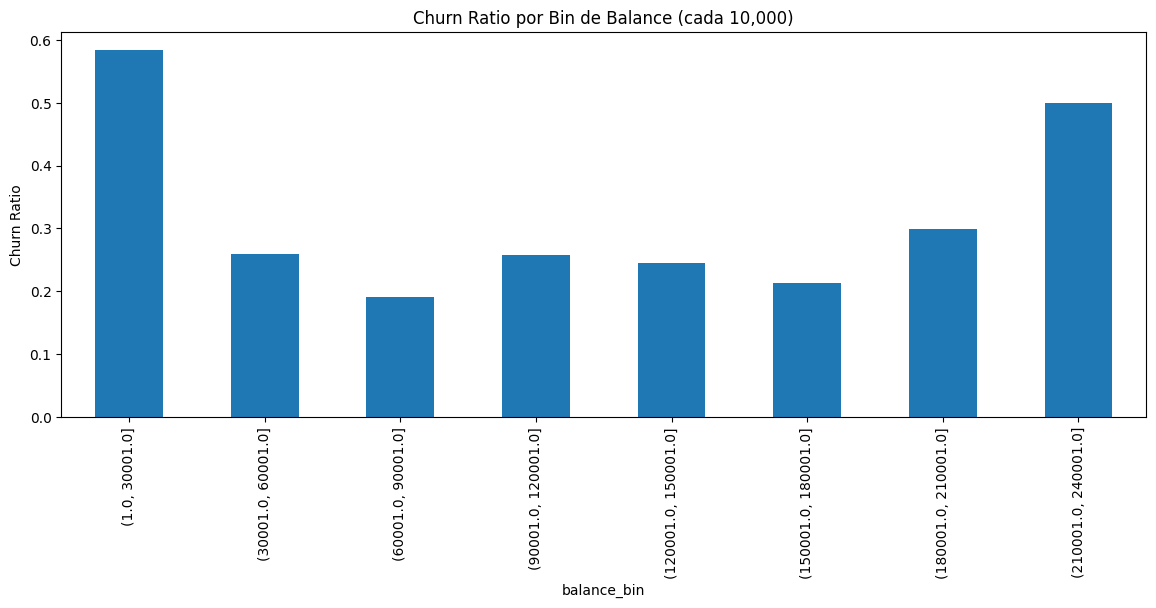

In [48]:
# Calcular la ratio de churned para cada grupo de Balance en bins de 10000
balance_bins = np.arange(1, df['Balance'].max() + 10000, 30000)
df['balance_bin'] = pd.cut(df['Balance'], bins=balance_bins)
churn_ratio_by_bin = df.groupby('balance_bin')['Churned'].mean()
print(churn_ratio_by_bin)
churn_ratio_by_bin.plot(kind='bar', figsize=(14,5))
plt.ylabel('Churn Ratio')
plt.title('Churn Ratio por Bin de Balance (cada 10,000)')
plt.show()